In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

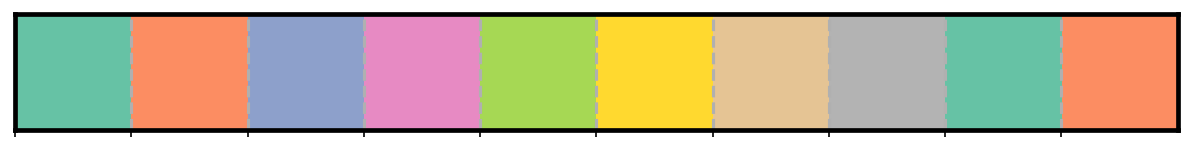

In [3]:




def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [4]:
signal_train = np.genfromtxt('BDT_signal_train.txt')
signal_test = np.genfromtxt('BDT_signal_test.txt')
background_train = np.genfromtxt('BDT_background_train.txt')
background_test = np.genfromtxt('BDT_background_test.txt')

In [5]:
background_train

array([[ 1.881091,  2.375811,  8.285966],
       [ 2.402203,  3.00813 , 13.030533],
       [ 4.061991,  3.379065, 25.449992],
       ...,
       [ 1.750617,  3.100183, 10.729395],
       [ 2.957329,  3.242218, 17.054168],
       [ 0.437191,  2.471685,  5.288993]], shape=(4000, 3))

In [6]:
x_b_train = background_train[:, 0]
x_s_train = signal_train[:, 0]
x_b_test = background_test[:, 0]
x_s_test = signal_test[:, 0]

y_b_train = background_train[:, 1]
y_s_train = signal_train[:, 1]
y_b_test = background_test[:, 1]
y_s_test = signal_test[:, 1]

z_b_train = background_train[:, 2]
z_s_train = signal_train[:, 2]
z_b_test = background_test[:, 2]
z_s_test = signal_test[:, 2] 

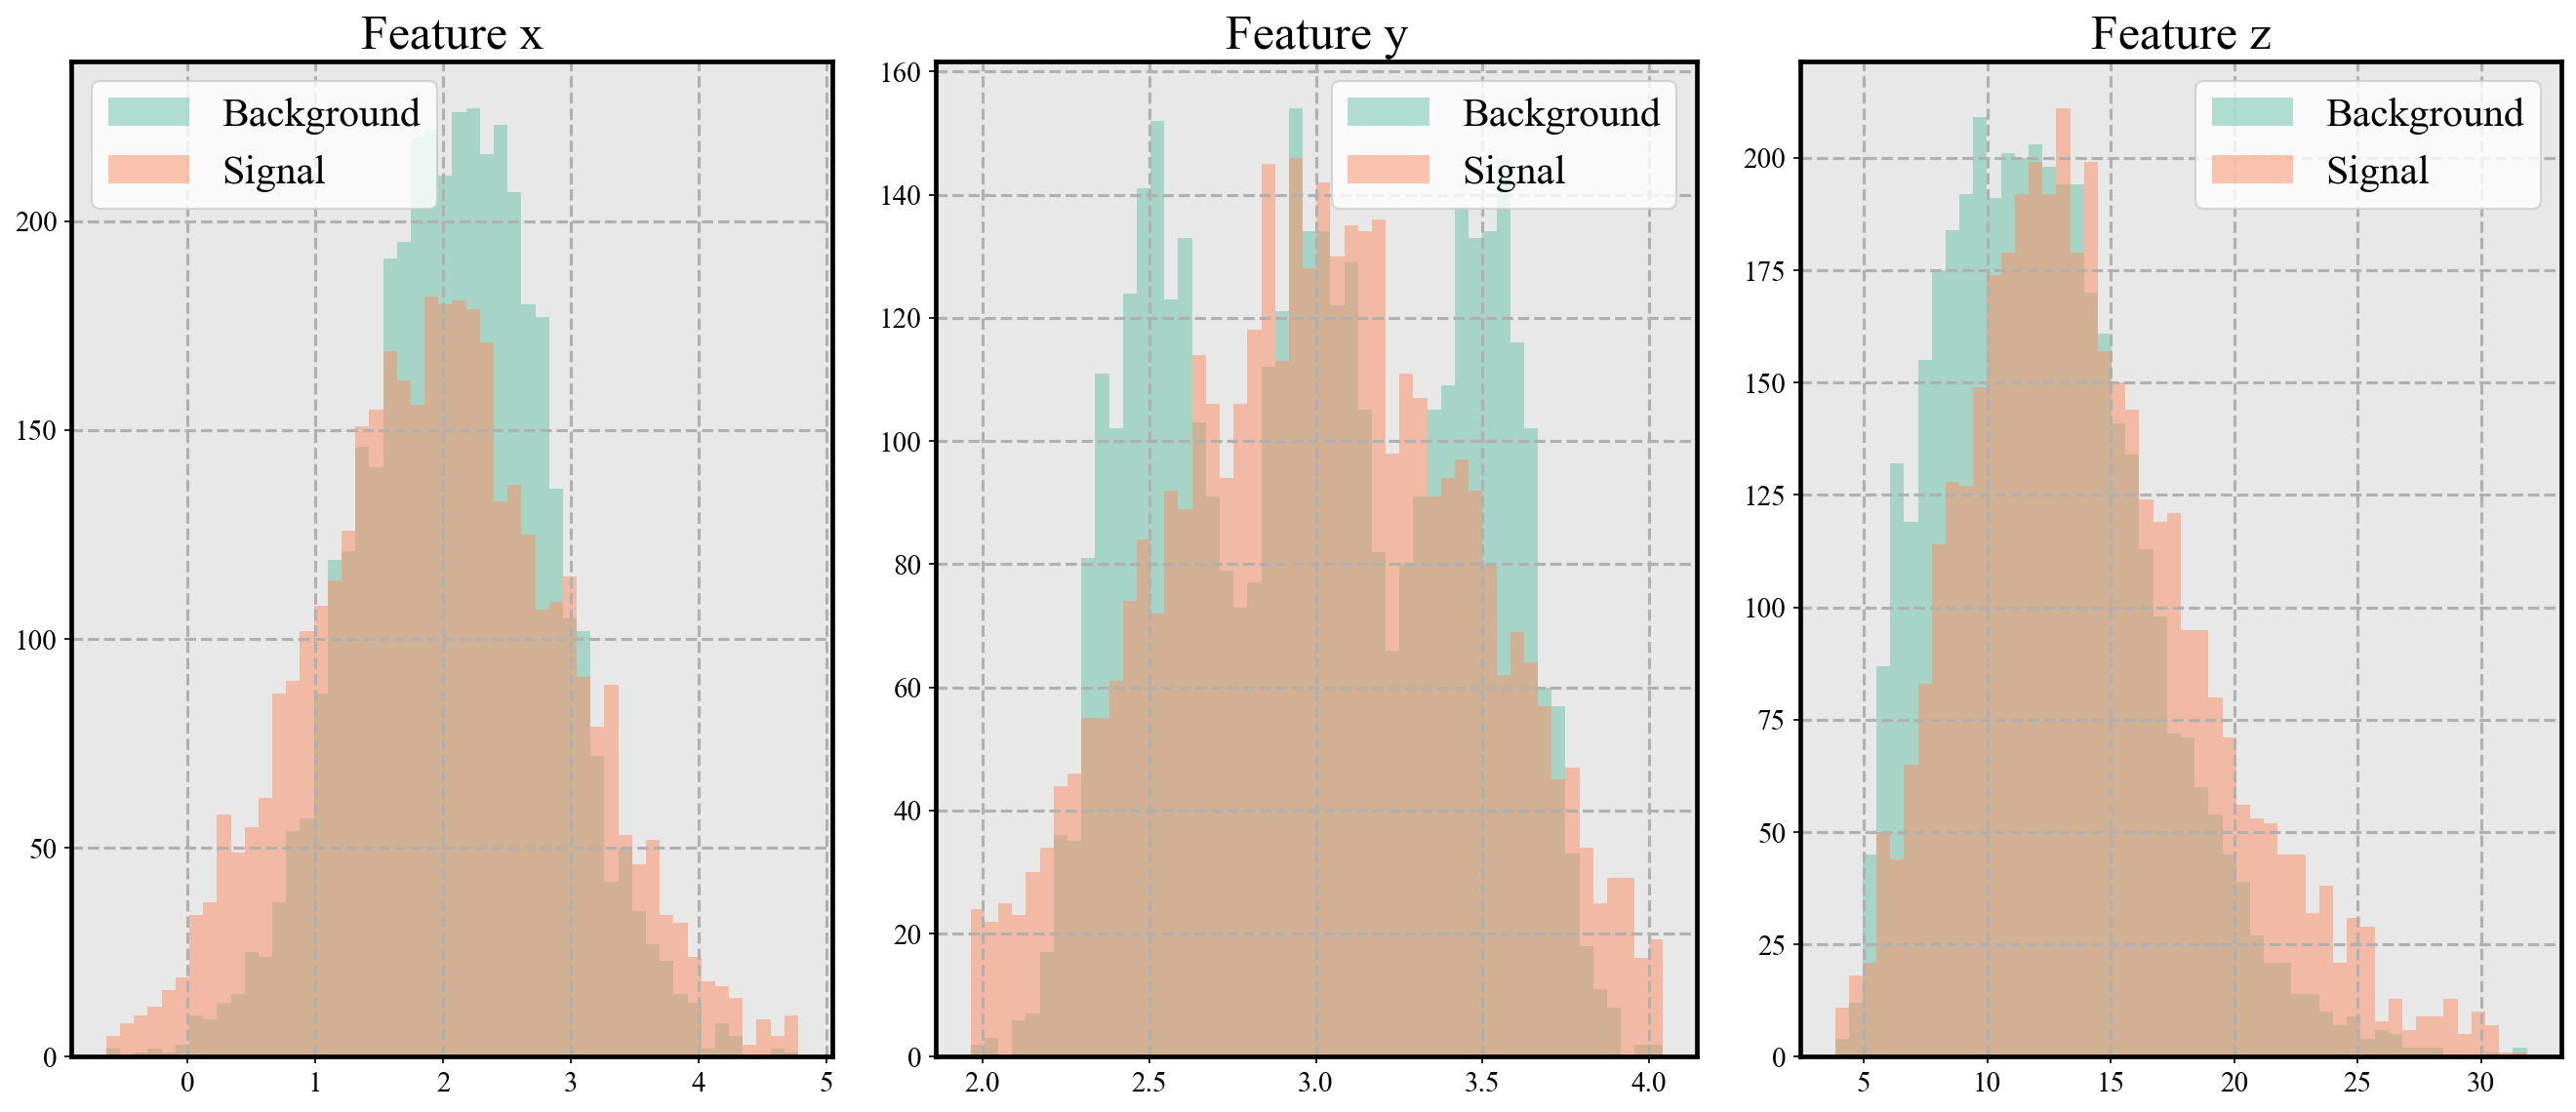

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))
counts, bins, _ = ax[0].hist(x_b_train, bins=50, alpha=0.5, label='Background')
ax[0].hist(x_s_train, bins=bins, alpha=0.5, label='Signal')
ax[0].set_title('Feature x')
ax[0].legend()
counts, bins, _ = ax[1].hist(y_b_train, bins=50, alpha=0.5, label='Background')
ax[1].hist(y_s_train, bins=bins, alpha=0.5, label='Signal')
ax[1].set_title('Feature y')
ax[1].legend()
counts, bins, _ = ax[2].hist(z_b_train, bins=50, alpha=0.5, label='Background')
ax[2].hist(z_s_train, bins=bins, alpha=0.5, label='Signal')
ax[2].set_title('Feature z')
ax[2].legend()
plt.tight_layout()
plt.show()

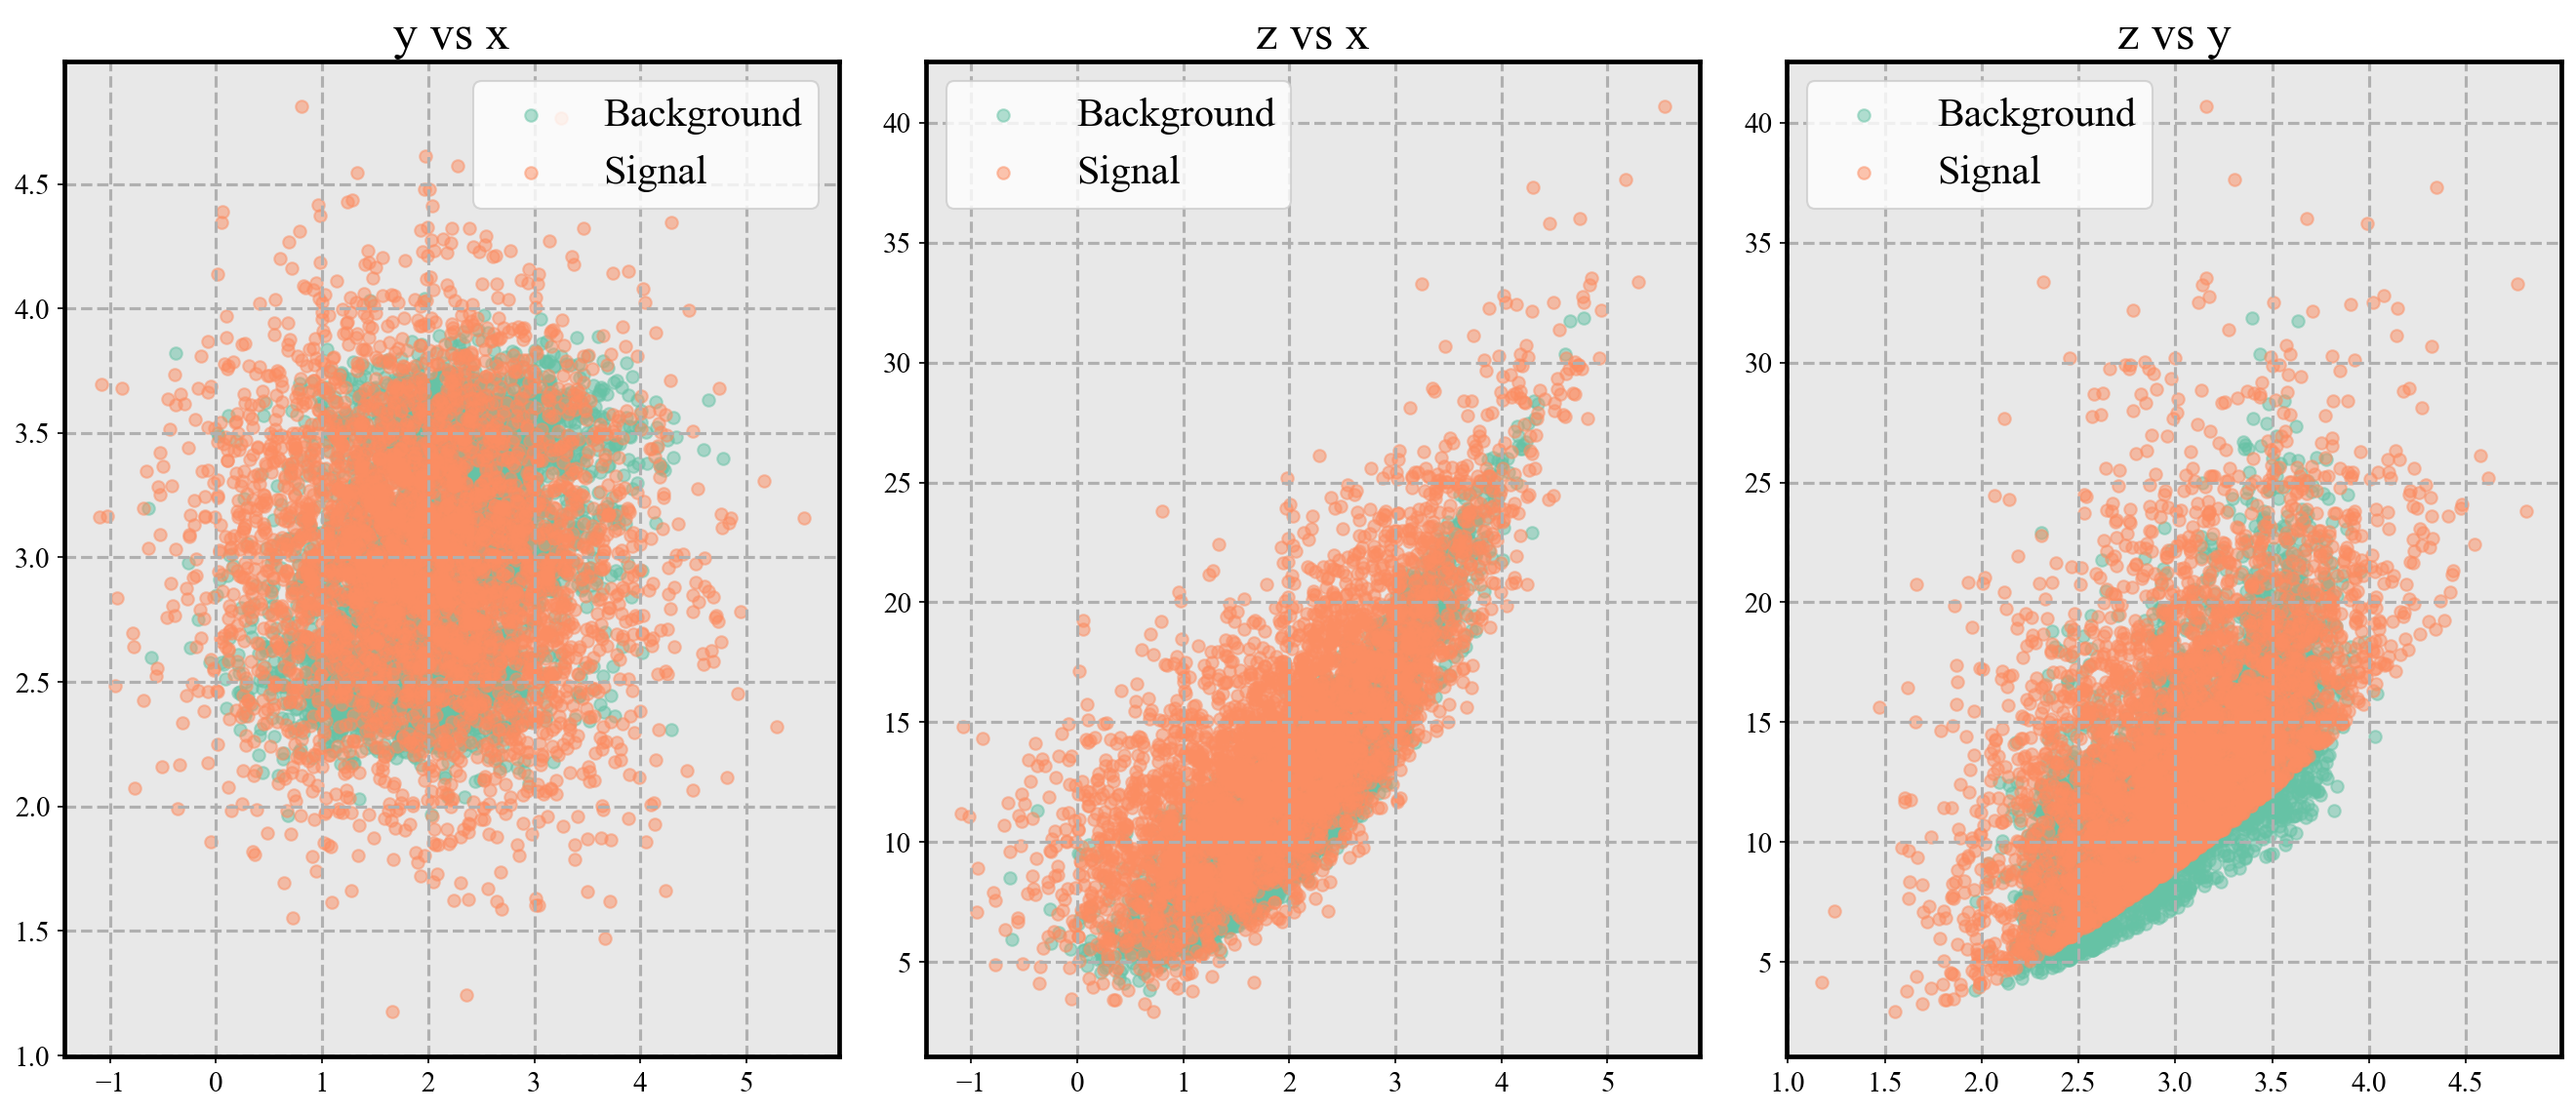

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))
ax[0].scatter(x_b_train, y_b_train, alpha=0.5, label='Background')
ax[0].scatter(x_s_train, y_s_train, alpha=0.5, label='Signal')
ax[1].scatter(x_b_train, z_b_train, alpha=0.5, label='Background')
ax[1].scatter(x_s_train, z_s_train, alpha=0.5, label='Signal')
ax[2].scatter(y_b_train, z_b_train, alpha=0.5, label='Background')
ax[2].scatter(y_s_train, z_s_train, alpha=0.5, label='Signal')
ax[0].set_title('y vs x')
ax[1].set_title('z vs x')
ax[2].set_title('z vs y')
for i in range(3):
    ax[i].legend()
plt.tight_layout()
plt.show()


In [9]:
X_train = np.vstack([background_train, signal_train])
y_train = np.concatenate([
    np.zeros(len(background_train)), 
    np.ones(len(signal_train))        
])
X_test = np.vstack([background_test, signal_test])
y_test = np.concatenate([
    np.zeros(len(background_test)), 
    np.ones(len(signal_test))        
])


In [10]:
BDT_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42)
BDT_model.fit(X_train, y_train) #format: (training data, training labels)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

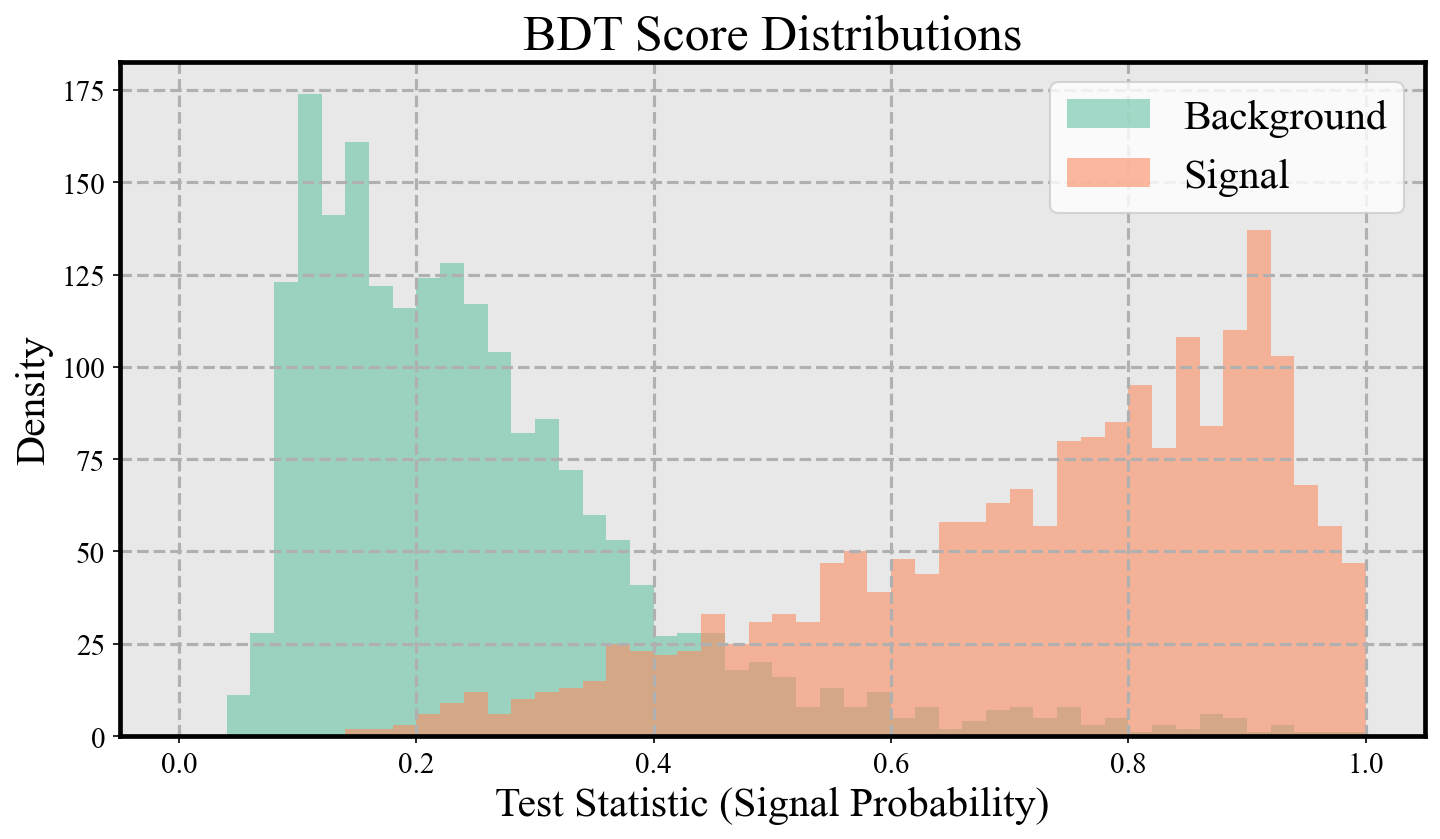

In [11]:
y_pred_proba = BDT_model.predict_proba(X_test)
test_statistic = y_pred_proba[:, 1]  # Probability of being signal (0-1)

# Separate by class
background_scores = test_statistic[:len(background_test)]
signal_scores = test_statistic[len(background_test):]

# Plot distributions
Nbins = 50
xrange = (0,1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(background_scores, bins=Nbins, range=xrange, alpha=0.6, label='Background', density=False)
ax.hist(signal_scores, bins=Nbins, range=xrange, alpha=0.6, label='Signal', density=False)
ax.set_xlabel('Test Statistic (Signal Probability)')
ax.set_ylabel('Density')
ax.set_title('BDT Score Distributions')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = BDT_model.predict(X_test)           # Class predictions (0 or 1)
y_pred_proba = BDT_model.predict_proba(X_test)  # Probabilities
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8980
AUC: 0.9593
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      2000
         1.0       0.93      0.86      0.89      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000

